In [2]:
import os, time

import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LogNorm
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable 

from skrmt.ensemble.spectral_law import MarchenkoPasturDistribution

# Following options are dependant on https://github.com/chanjure/global_chanju.git
# However, this is just an aesthetic package for plotting, so it is not necessary.
from global_chanju.paulplot.styles import nice_style
from global_chanju.paulplot.rc_setter import set_rc
from global_chanju.paulplot.rc_setter import get_rc
from global_chanju.utils.statistics import asym_err
from global_chanju.utils.statistics import f_bin
from global_chanju.paulplot.styles import base_ten


set_rc() # Setting global chanju plotting scheme

import pandas as pd
from pathlib import Path

In [7]:
plot_dir3 = "../images/3.prop/"
data_dir3 = "../data/3.prop/"

os.system("mkdir -p " + plot_dir3)
os.system("mkdir -p " + data_dir3)

0

In [8]:
data_dir = Path(data_dir3+"sgd_bbp_sweep")

csv_files = sorted(data_dir.glob("*.csv"))

if len(csv_files) == 0:
    raise ValueError(f"No CSV files found in {data_dir}")
    
df_exp = pd.concat(
    [pd.read_csv(f) for f in csv_files],
    ignore_index=True
)

print(df_exp.head(5))

   alpha    N    M     P  rep  epsilon  top_eval  teacher_overlap
0   10.0  100  200  2000    0     0.05  2.564515         0.029156
1   10.0  100  200  2000    0     0.10  2.307620         0.034374
2   10.0  100  200  2000    0     0.15  2.070182         0.041199
3   10.0  100  200  2000    0     0.20  1.852186         0.050531
4   10.0  100  200  2000    0     0.25  1.653827         0.063412


In [10]:
theory_dir = Path(data_dir3+"sgd_theory")

csv_files = sorted(theory_dir.glob("theory*.csv"))

if len(csv_files) == 0:
    raise ValueError(f"No CSV files found in {theory_dir}")
    
df_thr = pd.concat(
    [pd.read_csv(f) for f in csv_files],
    ignore_index=True
)

print(df_thr.head(5))

   alpha    r  sigmaW   epsilon      edge  outlier  overlap    margin  epscrit
0   10.0  0.5     1.0  0.050000  2.632839      NaN      0.0 -0.995762  0.53925
1   10.0  0.5     1.0  0.053908  2.611691      NaN      0.0 -0.995041  0.53925
2   10.0  0.5     1.0  0.057816  2.590665      NaN      0.0 -0.994258  0.53925
3   10.0  0.5     1.0  0.061723  2.569761      NaN      0.0 -0.993412  0.53925
4   10.0  0.5     1.0  0.065631  2.548978      NaN      0.0 -0.992502  0.53925


In [11]:
alpha = np.sort(np.unique(df_exp.alpha))
print(alpha)

runs = np.sort(np.unique(df_exp.rep))
print(runs)

Ns = np.sort(np.unique(df_exp.N))
print(Ns)
Ns = Ns[1::2]
print(Ns)
Ns = [12800]

[ 1.  3.  5. 10. 50.]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
[  100   200   400   800  1600  3200  6400 12800]
[  200   800  3200 12800]


In [12]:
alpha_plot = 10
n = len(runs)

epsilon_list = df_exp[(df_exp["alpha"] == alpha_plot) & (df_exp["rep"] == 0) & (df_exp["N"] == 800)]["epsilon"].values

top_eval = np.empty((len(epsilon_list), len(Ns), n))
teacher_overlap = np.empty((len(epsilon_list), len(Ns), n))

for i in range(len(runs)):
    for j in range(len(Ns)):
        top_eval[:, j, i] = df_exp[(df_exp["alpha"] == alpha_plot) & (df_exp["rep"] == i) & (df_exp["N"] == Ns[j])][["top_eval"]].values.ravel()
        teacher_overlap[:, j, i] = df_exp[(df_exp["alpha"] == alpha_plot) & (df_exp["rep"] == i) & (df_exp["N"] == Ns[j])][["teacher_overlap"]].values.ravel()

In [13]:
df_thr_alpha = df_thr[(df_thr["alpha"] == alpha_plot)].sort_values(["epsilon"])
epsilon_list_thr = df_thr_alpha["epsilon"].values
top_eval_thr = df_thr_alpha["outlier"].values
edge_thr = df_thr_alpha["edge"].values
overlap_thr = df_thr_alpha["overlap"].values
eps_c = df_thr_alpha['epscrit'].values[0]
eps_c_upper = df_thr_alpha[df_thr_alpha["overlap"] != 0]["epsilon"].values[-1]

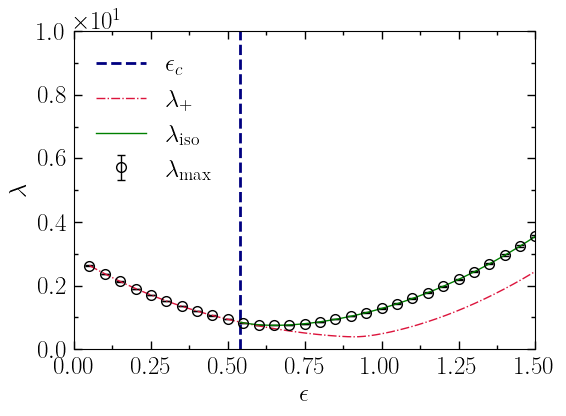

In [14]:
n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

cmap = plt.cm.inferno(np.linspace(0.1, 0.8, len(Ns)))

for i in range(len(Ns)):
    mean, err = asym_err(top_eval[:,i], axis=-1)
    axs.errorbar(epsilon_list, mean, yerr=err,
                 color='k', alpha=1, ls='',
                 label=r"$\lambda_{\rm max}$"
                )

axs.axvline(eps_c, ls='--', color='navy', lw=2, label=r"$\epsilon_c$")
axs.axvline(eps_c_upper, ls='--', color='navy', lw=2)
    
axs.plot(epsilon_list_thr, edge_thr, 
         color='crimson', lw=1, ls='-.', marker='',
         label=r"$\lambda_{+}$")

axs.plot(epsilon_list_thr, top_eval_thr, 
         color='green', lw=1, ls='-', marker='',
         label=r"$\lambda_{\rm iso}$")
    
nice_style(axs, 
           xlim=(0., 1.5), ylim=(0., 10.), 
           xlabel=r"$\epsilon$", 
           ylabel=r"$\lambda$")

axs.legend(loc='upper left')

plt.savefig(plot_dir3+"prop_lambda_alpha%d.pdf"%(alpha_plot))

plt.show()

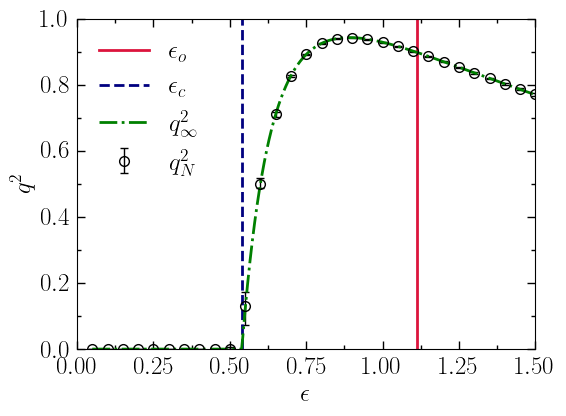

In [15]:
n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

cmap = plt.cm.inferno(np.linspace(0.1, 0.8, len(Ns)))

for i in range(len(Ns)):
    mean, err = asym_err(teacher_overlap[:,i], axis=-1)
    axs.errorbar(epsilon_list, mean, yerr=err,
                 color='k', alpha=1., ls='',
                 label=r"$q_N^2$"
                )

epsilon_o = alpha_plot / (alpha_plot - 1. + 1e-10)
axs.axvline(epsilon_o, ls='-', color='crimson', lw=2, label=r"$\epsilon_o$")

axs.axvline(eps_c, ls='--', color='navy', lw=2, label=r"$\epsilon_c$")

axs.plot(
    epsilon_list_thr, overlap_thr, 
    color='green', lw=2, marker='', ls='-.',
    label=r"$q^2_{\infty}$"
)

nice_style(axs, 
           xlim=(0., 1.5), ylim=(0., 1.), 
           xlabel=r"$\epsilon$", 
           ylabel=r"$q^2$")

axs.legend(loc="upper left")

plt.savefig(plot_dir3+"overlap_alpha%d.pdf"%(alpha_plot))

plt.show()

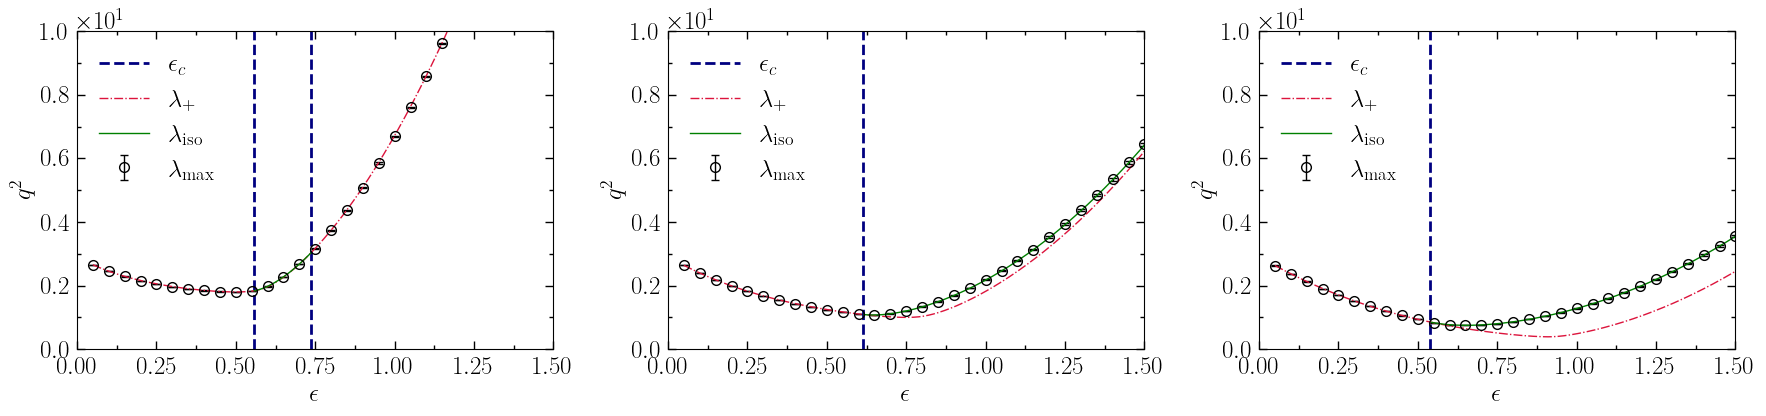

In [16]:
n_fig = 3
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))
Ns = [12800]
alpha_list = [1, 3, 10]
for k, a in enumerate(alpha_list):
    alpha_plot = a
    n = len(runs)

    epsilon_list = df_exp[(df_exp["alpha"] == alpha_plot) & (df_exp["rep"] == 0) & (df_exp["N"] == 800)]["epsilon"].values

    top_eval = np.empty((len(epsilon_list), len(Ns), n))
    teacher_overlap = np.empty((len(epsilon_list), len(Ns), n))

    for i in range(len(runs)):
        for j in range(len(Ns)):
            top_eval[:, j, i] = df_exp[(df_exp["alpha"] == alpha_plot) & (df_exp["rep"] == i) & (df_exp["N"] == Ns[j])][["top_eval"]].values.ravel()
            teacher_overlap[:, j, i] = df_exp[(df_exp["alpha"] == alpha_plot) & (df_exp["rep"] == i) & (df_exp["N"] == Ns[j])][["teacher_overlap"]].values.ravel()

    df_thr_alpha = df_thr[(df_thr["alpha"] == alpha_plot)].sort_values(["epsilon"])
    epsilon_list_thr = df_thr_alpha["epsilon"].values
    top_eval_thr = df_thr_alpha["outlier"].values
    edge_thr = df_thr_alpha["edge"].values
    overlap_thr = df_thr_alpha["overlap"].values
    eps_c = df_thr_alpha['epscrit'].values[0]
    eps_c_upper = df_thr_alpha[df_thr_alpha["overlap"] != 0]["epsilon"].values[-1]

    cmap = plt.cm.inferno(np.linspace(0.1, 0.8, len(Ns)))

    for i in range(len(Ns)):
        mean, err = asym_err(top_eval[:, i], axis=-1)
        axs[k].errorbar(
            epsilon_list, mean, yerr=err,
            color='k', alpha=1, ls='',
            label=r"$\lambda_{\rm max}$"
        )

    axs[k].axvline(eps_c, ls='--', color='navy', lw=2, label=r"$\epsilon_c$")
    axs[k].axvline(eps_c_upper, ls='--', color='navy', lw=2)

    axs[k].plot(epsilon_list_thr, edge_thr, 
             color='crimson', lw=1, ls='-.', marker='',
             label=r"$\lambda_{+}$")

    axs[k].plot(epsilon_list_thr, top_eval_thr, 
             color='green', lw=1, ls='-', marker='',
             label=r"$\lambda_{\rm iso}$")

    nice_style(axs[k], 
               xlim=(0., 1.5), ylim=(0., 10.), 
               xlabel=r"$\epsilon$", 
               ylabel=r"$q^2$")

    axs[k].legend(loc='upper left')

plt.savefig(plot_dir3+"prop_lambda_alpha_all.pdf")

plt.show()

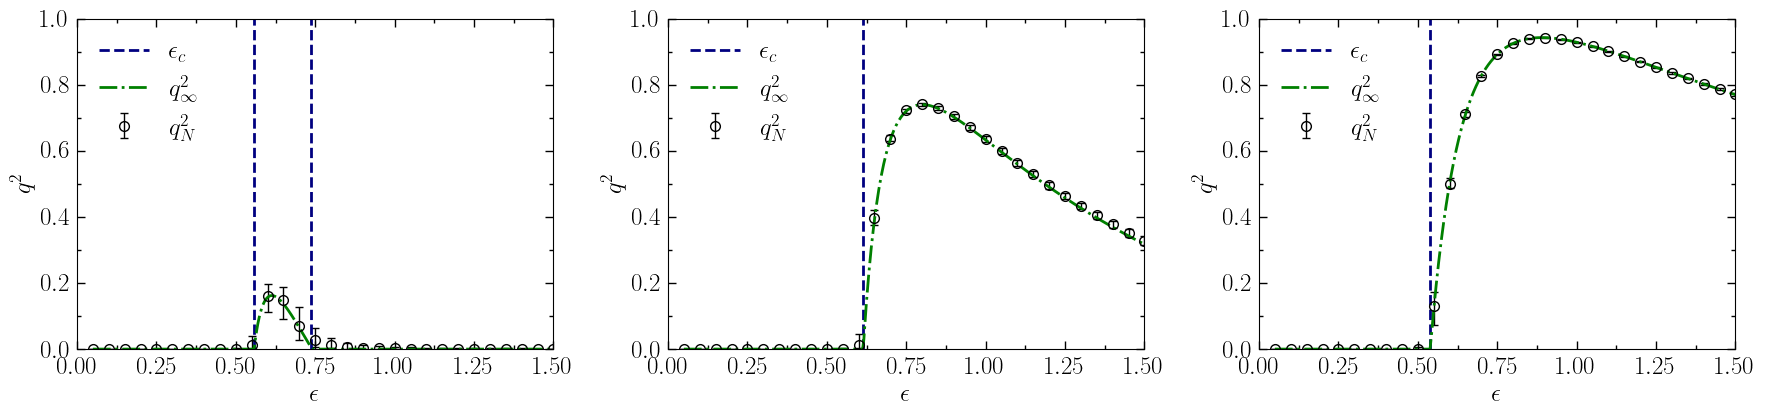

In [17]:
n_fig = 3
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))
Ns = [12800]
alpha_list = [1, 3, 10]
for k, a in enumerate(alpha_list):
    alpha_plot = a
    n = len(runs)

    epsilon_list = df_exp[(df_exp["alpha"] == alpha_plot) & (df_exp["rep"] == 0) & (df_exp["N"] == 800)]["epsilon"].values

    top_eval = np.empty((len(epsilon_list), len(Ns), n))
    teacher_overlap = np.empty((len(epsilon_list), len(Ns), n))

    for i in range(len(runs)):
        for j in range(len(Ns)):
            top_eval[:, j, i] = df_exp[(df_exp["alpha"] == alpha_plot) & (df_exp["rep"] == i) & (df_exp["N"] == Ns[j])][["top_eval"]].values.ravel()
            teacher_overlap[:, j, i] = df_exp[(df_exp["alpha"] == alpha_plot) & (df_exp["rep"] == i) & (df_exp["N"] == Ns[j])][["teacher_overlap"]].values.ravel()

    df_thr_alpha = df_thr[(df_thr["alpha"] == alpha_plot)].sort_values(["epsilon"])
    epsilon_list_thr = df_thr_alpha["epsilon"].values
    top_eval_thr = df_thr_alpha["outlier"].values
    edge_thr = df_thr_alpha["edge"].values
    overlap_thr = df_thr_alpha["overlap"].values
    eps_c = df_thr_alpha['epscrit'].values[0]
    eps_c_upper = df_thr_alpha[df_thr_alpha["overlap"] != 0]["epsilon"].values[-1]

    cmap = plt.cm.inferno(np.linspace(0.1, 0.8, len(Ns)))

    for i in range(len(Ns)):
        mean, err = asym_err(teacher_overlap[:,i], axis=-1)
        axs[k].errorbar(epsilon_list, mean, yerr=err,
                     color='k', alpha=1., ls='',
                     label=r"$q_N^2$"
                    )

    axs[k].axvline(eps_c, ls='--', color='navy', lw=2, label=r"$\epsilon_c$")
    axs[k].axvline(eps_c_upper, ls='--', color='navy', lw=2)

    axs[k].plot(
        epsilon_list_thr, overlap_thr, 
        color='green', lw=2, marker='', ls='-.',
        label=r"$q^2_{\infty}$"
    )

    nice_style(axs[k], 
               xlim=(0., 1.5), ylim=(0., 1.), 
               xlabel=r"$\epsilon$", 
               ylabel=r"$q^2$")

    axs[k].legend(loc='upper left')

plt.savefig(plot_dir3+"prop_overlap_alpha_all.pdf")

plt.show()

# Finite size scaling

In [18]:
Ns = np.sort(np.unique(df_exp.N))
print(Ns)
Ns = Ns[1::2]

alpha_plot = 3
n = len(runs)

epsilon_list = df_exp[(df_exp["alpha"] == alpha_plot) & (df_exp["rep"] == 0) & (df_exp["N"] == 800)]["epsilon"].values

top_eval = np.empty((len(epsilon_list), len(Ns), n))
teacher_overlap = np.empty((len(epsilon_list), len(Ns), n))

for i in range(len(runs)):
    for j in range(len(Ns)):
        top_eval[:, j, i] = df_exp[(df_exp["alpha"] == alpha_plot) & (df_exp["rep"] == i) & (df_exp["N"] == Ns[j])][["top_eval"]].values.ravel()
        teacher_overlap[:, j, i] = df_exp[(df_exp["alpha"] == alpha_plot) & (df_exp["rep"] == i) & (df_exp["N"] == Ns[j])][["teacher_overlap"]].values.ravel()
        
df_thr_alpha = df_thr[(df_thr["alpha"] == alpha_plot)].sort_values(["epsilon"]).dropna()
epsilon_list_thr = df_thr_alpha["epsilon"].values
top_eval_thr = df_thr_alpha["outlier"].values
edge_thr = df_thr_alpha["edge"].values
overlap_thr = df_thr_alpha["overlap"].values
eps_c = df_thr_alpha['epscrit'].values[0]

[  100   200   400   800  1600  3200  6400 12800]


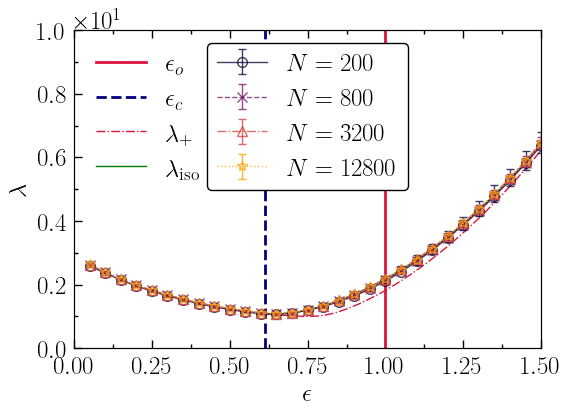

In [19]:
n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

cmap = plt.cm.inferno(np.linspace(0.1, 0.8, len(Ns)))

axs_sub = axs.twinx()

for i in range(len(Ns)):
    mean, err = asym_err(top_eval[:,i], axis=-1)
    axs_sub.errorbar(epsilon_list, mean, yerr=err,
                     color=cmap[i], alpha=0.8,
                     label=r"$N = %d$"%(Ns[i])
                    )
    
axs.axvline(1, ls='-', color='crimson', lw=2, label=r"$\epsilon_o$")

axs.axvline(eps_c, ls='--', color='navy', lw=2, label=r"$\epsilon_c$")
    
axs.plot(epsilon_list_thr, edge_thr, 
         color='crimson', lw=1, ls='-.', marker='',
         label=r"$\lambda_{+}$")

axs.plot(epsilon_list_thr, top_eval_thr, 
         color='green', lw=1, ls='-', marker='',
         label=r"$\lambda_{\rm iso}$")
    
nice_style(axs, 
           xlim=(0., 1.5), ylim=(0., 10.), 
           xlabel=r"$\epsilon$", 
           ylabel=r"$\lambda$")

nice_style(axs_sub, 
           xlim=(0., 1.5), ylim=(0., 10.), 
           xlabel=r"", 
           ylabel=r"",
           yticks=[]
          )

axs.legend(loc='upper left')
axs_sub.legend(loc='upper center', facecolor='white', frameon=True, framealpha=1, edgecolor='k', fancybox=True)

plt.savefig(plot_dir3+"prop_lambda_alpha%d_fss.pdf"%(alpha_plot))

plt.show()

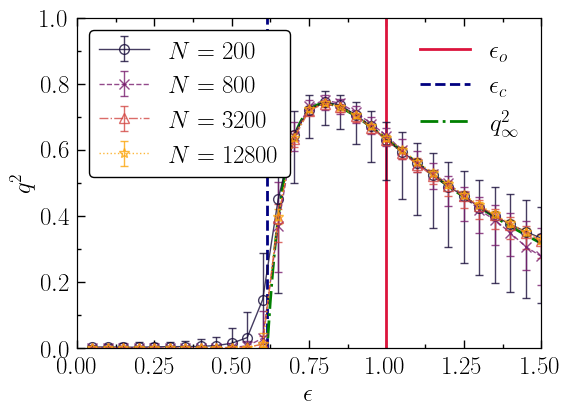

In [20]:
n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

cmap = plt.cm.inferno(np.linspace(0.1, 0.8, len(Ns)))

axs_sub = axs.twinx()

for i in range(len(Ns)):
    mean, err = asym_err(teacher_overlap[:,i], axis=-1)
    axs_sub.errorbar(epsilon_list, mean, yerr=err,
                     color=cmap[i], alpha=0.8,
                     label=r"$N = %d$"%(Ns[i])
                    )
    
axs.axvline(1, ls='-', color='crimson', lw=2, label=r"$\epsilon_o$")

axs.axvline(eps_c, ls='--', color='navy', lw=2, label=r"$\epsilon_c$")

axs.plot(
    epsilon_list_thr, overlap_thr, 
    color='green', lw=2, marker='', ls='-.',
    label=r"$q^2_{\infty}$"
)

nice_style(axs, 
           xlim=(0., 1.5), ylim=(0., 1.), 
           xlabel=r"$\epsilon$", 
           ylabel=r"$q^2$")

nice_style(axs_sub, 
           xlim=(0., 1.5), ylim=(0., 1.), 
           xlabel=r"", 
           ylabel=r"",
           yticks=[]
          )

axs.legend(loc="upper right")
axs_sub.legend(loc="upper left", facecolor='white', frameon=True, framealpha=1, edgecolor='k', fancybox=True)

plt.savefig(plot_dir3+"overlap_alpha%d_fss.pdf"%(alpha_plot))

plt.show()

# $\epsilon_c(\alpha)$ Phase Diagram

In [23]:
df = pd.read_csv(data_dir3+"eps_sig_phase.csv")
epsilon_grid = np.unique(
    np.concatenate([
        10.0 ** np.linspace(-2.3, 2.3, 520),
        [1.0]
    ])
)
alphas = df.keys().values

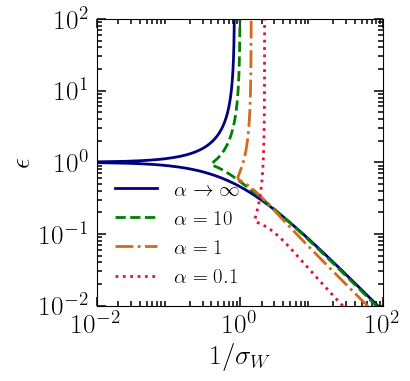

In [24]:
labels = [r"$\alpha \to \infty$",
          r"$\alpha = 10$",
          r"$\alpha = 1$",
          r"$\alpha = 0.1$"
         ]

colours = ["navy",
           "green",
           "chocolate",
           "crimson",
          ]

set_rc(scale=1.1)
n_fig = 1

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

alphas = ['0.1', '1.0', '10.0', 'Inf']

for i, a in enumerate(alphas[::-1]):
    inv_sig = df[a].values

    axs.plot(
        inv_sig, epsilon_grid,
        marker='', lw=2,
        color=colours[i],
        label=labels[i]
    )

nice_style(axs, 
           ylim=(1e-2, 1e2),
           xlim=(1e-2, 1e2),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

plt.legend(loc="lower left", fontsize=15)

plt.savefig(plot_dir3+"eps_c_alpha.pdf")
plt.show()

# $\epsilon_c - \alpha$ Phase Diagram 

In [25]:
import json

In [26]:
with open(data_dir3+"eps_alpha_phase.json") as f:
    crits_by_alpha = json.load(f)

In [27]:
crits_lower = []
crits_upper = []

count = 0
for c in crits_by_alpha:
    if c == []:
        crits_lower.append(np.nan)
        crits_upper.append(np.nan)
        count+=1
    elif len(c) == 2:
        crits_lower.append(c[0])
        crits_upper.append(c[1])
    else:
        crits_lower.append(c[0])
        crits_upper.append(np.nan)
        
crits_lower = np.array(crits_lower)
crits_upper = np.array(crits_upper)

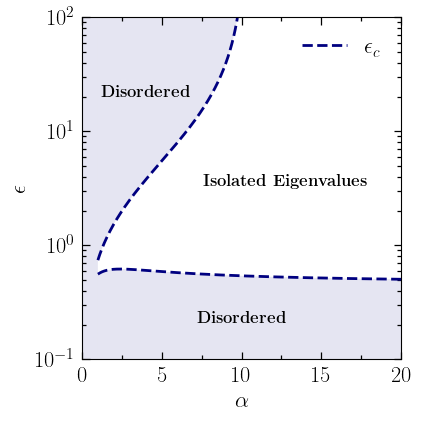

In [28]:
alphas = np.arange(1, 20.001, 0.01)

set_rc(scale=0.9)
n_fig = 1

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

axs.plot(
    alphas, crits_lower,
    marker='', color='navy',
    lw=2, ls='--',
    label=r"$\epsilon_c$"
)

axs.plot(
    alphas, crits_upper,
    marker='', color='navy',
    lw=2, ls='--'
)

axs.fill_between(
    alphas, 
    y1=crits_upper, y2=1e2, 
    facecolor='navy', alpha=0.1, hatch='')

axs.fill_between(
    alphas, 
    y1=1e-2, y2=crits_lower, 
    facecolor='navy', alpha=0.1, hatch='')

axs.fill_between(
    np.linspace(0, alphas[count], 1000), 
    y1=1e-2, y2=1e2, 
    facecolor='navy', alpha=0.1, hatch='')

fontsize=12
axs.text(
    0.38, 0.52,
    transform=axs.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"\bf Isolated Eigenvalues",
    fontsize=fontsize
)

axs.text(
    0.06, 0.78,
    transform=axs.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"\bf Disordered",
    fontsize=fontsize
)

axs.text(
    0.36, 0.12,
    transform=axs.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"\bf Disordered",
    fontsize=fontsize
)

nice_style(
    axs, 
    ylim=(1e-1, 1e2),
    xlim=(0, 20),
    xlabel=r"$\alpha$",
    ylabel=r"$\epsilon$",
    logx=False, logy=True
)


plt.legend(loc='upper right', 
           facecolor='white', 
           frameon=False, framealpha=1, edgecolor='k', fancybox=True)
plt.tight_layout()

plt.savefig(plot_dir3+"eps_alpha_plot.pdf")
plt.show()